Epoch 1/1000
188/188 [==============================] - 1s 2ms/step - loss: 0.4783 - accuracy: 0.9403
Epoch 2/1000
188/188 [==============================] - 0s 2ms/step - loss: 0.1880 - accuracy: 0.9064
Epoch 3/1000
188/188 [==============================] - 0s 2ms/step - loss: 0.1222 - accuracy: 0.8361
Epoch 4/1000
188/188 [==============================] - 0s 1ms/step - loss: 0.0988 - accuracy: 0.7978
Epoch 5/1000
188/188 [==============================] - 0s 1ms/step - loss: 0.0886 - accuracy: 0.7813
Epoch 6/1000
188/188 [==============================] - 0s 1ms/step - loss: 0.0800 - accuracy: 0.7728
Epoch 7/1000
188/188 [==============================] - 0s 1ms/step - loss: 0.0730 - accuracy: 0.7719
Epoch 8/1000
188/188 [==============================] - 0s 1ms/step - loss: 0.0673 - accuracy: 0.7624
Epoch 9/1000
188/188 [==============================] - 0s 1ms/step - loss: 0.0611 - accuracy: 0.7639
Epoch 10/1000
188/188 [==============================] - 0s 1ms/step - loss: 0.057

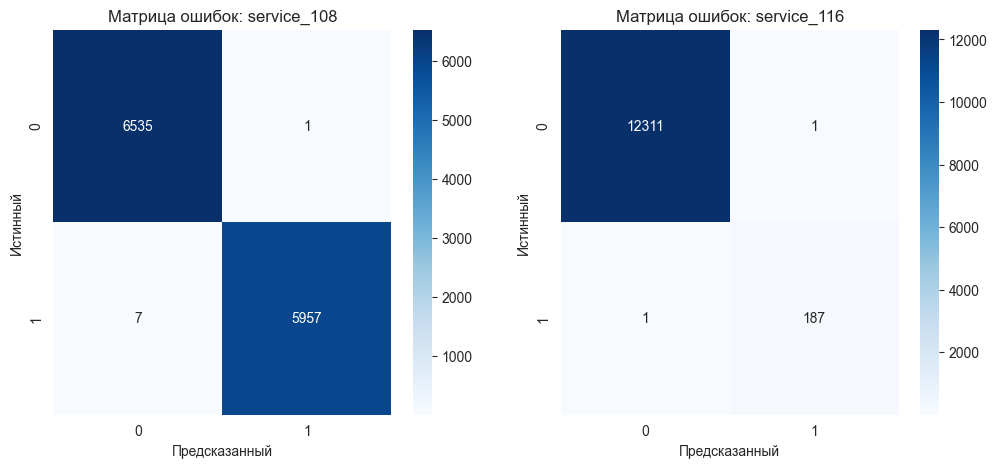

Ошибочные предсказания для service_108


,age,child_number,family_size,income_childEveryMonthPosob_Oro,income_edvThirdChild,study_certificate,true_target,pred_target,prob_target
16678,6,1,4,67832.01,131842.48,0,1,0,0.482662
17280,8,1,2,33869.83,75240.58,0,1,0,0.482235
5201,8,3,4,67932.02,148478.42,0,0,1,0.546743
3659,12,2,3,50899.87,127809.82,0,1,0,0.456677
39956,16,1,2,33766.26,52284.85,1,1,0,0.496466
31363,5,4,5,84785.90,251206.57,0,1,0,0.259323
40004,8,1,3,50910.93,87634.58,0,1,0,0.377212
36023,6,1,2,33894.34,71382.26,0,1,0,0.414209


Ошибочные предсказания для service_116


,age,child_number,family_size,income_childEveryMonthPosob_Oro,income_edvThirdChild,study_certificate,true_target,pred_target,prob_target
27227,2,7,8,121659.79,243695.48,0,1,0,0.021746
42366,2,3,5,200635.09,154460.46,0,0,1,0.953469


Модель сохранена в models\servicePredictor_108_116_tf.onnx


In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import tf2onnx
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers

# Загружаем данные
file_path = '../resources/dataset_108_116_with_separate_incomes.csv'
data = pd.read_csv(file_path).drop_duplicates()

# Определяем признаки и целевые переменные (услуги)
features = ["age", "child_number", "family_size", "income_childEveryMonthPosob_Oro", "income_edvThirdChild", "study_certificate"]
service_columns = ["service_108", "service_116"]

X = data[features]
y = data[service_columns]

# Разделяем на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# Создаем слой нормализации
X_train_array = np.array(X_train, dtype=np.float32)
normalizer = layers.experimental.preprocessing.Normalization()
normalizer.adapt(X_train_array)  # Обучаем нормализатор на тренировочных данных

# Создаем модель с нормализацией внутри
model = keras.Sequential([
    normalizer,  # Встроенная нормализация
    layers.Dense(100, activation='relu', kernel_regularizer=regularizers.l2(1e-5)),
    layers.Dense(y_train.shape[1], activation='sigmoid')  # Выходной слой
])

# Компилируем модель
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Обучаем модель
history = model.fit(X_train, y_train, epochs=1000, batch_size=200, verbose=1)

# Прогнозируем
y_pred_prob = model.predict(X_test)  # Получаем вероятности предсказания
y_pred = (y_pred_prob > 0.5).astype(int)  # Бинаризуем предсказания

# Оценка точности по каждой услуге
for i, service in enumerate(service_columns):
    acc = accuracy_score(y_test[service], y_pred[:, i])
    print(f"Точность для {service}: {acc:.10f}")

# Визуализируем матрицы ошибок
fig, axes = plt.subplots(1, len(service_columns), figsize=(6 * len(service_columns), 5))

for i, service in enumerate(service_columns):
    cm = confusion_matrix(y_test[service], y_pred[:, i])
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", ax=axes[i])
    axes[i].set_title(f"Матрица ошибок: {service}")
    axes[i].set_xlabel("Предсказанный")
    axes[i].set_ylabel("Истинный")

plt.show()

# Анализ ошибок
for i, service in enumerate(service_columns):
    print(f"Ошибочные предсказания для {service}")
    wrong_idx = (y_test[service] != y_pred[:, i])
    errors = X_test[wrong_idx].copy()
    errors["true_target"] = y_test[service][wrong_idx]
    errors["pred_target"] = y_pred[:, i][wrong_idx]
    errors["prob_target"] = y_pred_prob[:, i][wrong_idx]
    display(errors)

# Сохраняем модель
spec = (tf.TensorSpec((None, X_train.shape[1]), tf.float32, name="input"),)
onnx_model, _ = tf2onnx.convert.from_keras(model, input_signature=spec, opset=11)

onnx_path = "models\\servicePredictor_108_116_tf.onnx"
with open(onnx_path, "wb") as f:
    f.write(onnx_model.SerializeToString())

print(f"Модель сохранена в {onnx_path}")

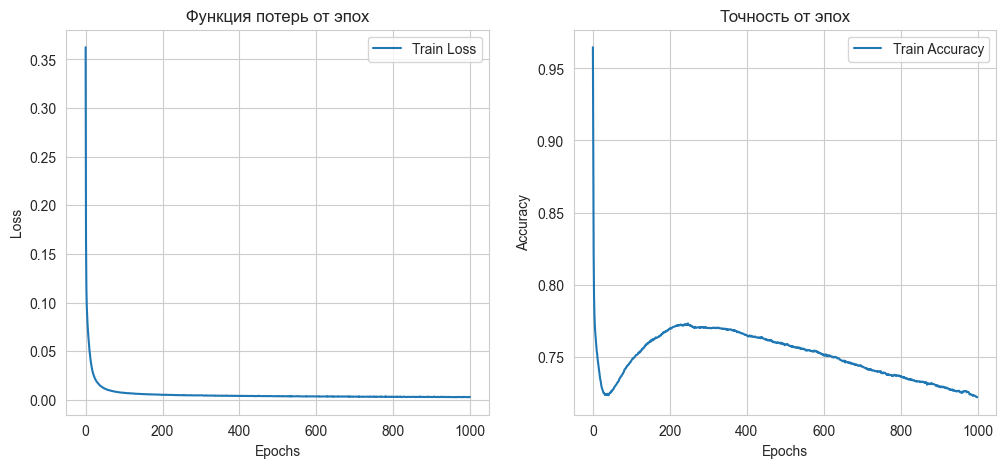

In [20]:
import matplotlib.pyplot as plt

# Графики функции потерь и точности
plt.figure(figsize=(12, 5))

# Потери
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Функция потерь от эпох')
plt.legend()

# Точность
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Точность от эпох')
plt.legend()

plt.show()


In [21]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Финальная точность на тесте: {acc:.4f}")

391/391 [==============================] - 0s 554us/step - loss: 0.0033 - accuracy: 0.7234
Финальная точность на тесте: 0.7234
